# spVIPES — Multi-group, Multimodal, and Normalizing-Flow-Prior Tutorial

This notebook showcases three features added to **spVIPES** in the
`multigroup-multimodal-support` branch:

| Feature | API |
|---|---|
| **N ≥ 2 groups** for disentanglement | `spVIPES.data.prepare_adatas` — generalised beyond 2 groups |
| **Multimodal (RNA + protein) integration** | `spVIPES.data.prepare_multimodal_adatas`, two-level Product of Experts (intra-group across modalities, inter-group across groups), per-modality likelihoods |
| **Zuko normalizing-flow prior** (NSF / MAF) on shared or private latents | `use_nf_prior`, `nf_type`, `nf_transforms`, `nf_target` on `spVIPES.model.spVIPES` |

We exercise all three features on a single public CITE-seq dataset
(`scvi.data.spleen_lymph_cite_seq()`), splitting the data into **three** groups
so that we go beyond the original 2-group cap. We then train two models
— one with the standard Gaussian prior and one with a Neural Spline Flow
(NSF) prior on the shared latent — and compare their embeddings both
qualitatively (UMAP) and quantitatively (batch mixing vs. label
conservation).

> **Runtime:** the notebook is sized to run on a laptop CPU in under
> ~10 minutes by subsampling to 1000 cells per group and 1000 highly-variable
> genes. Full-dataset parameters are given in commented-out cells for users
> with a GPU.

## Requirements & Compatibility

> **scvi-tools ≥1.0 required.** spVIPES targets scvi-tools 1.x and `lightning.pytorch` (was 0.20.x + `pytorch_lightning`). The deprecated `use_gpu=True` kwarg on `model.train(...)` has been **removed**; pass `accelerator="gpu", devices=1` (or `"auto"`) inside `**trainer_kwargs` instead. Minimum Python is 3.10. Several private scvi-tools modules removed in 1.x are now vendored under `spVIPES.data`. See `CHANGELOG.md` for full details.

## 1. Environment

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import scanpy as sc
import scvi
import torch
import matplotlib.pyplot as plt
import anndata as ad
import scipy.sparse as sp

import spVIPES

np.random.seed(0)
torch.manual_seed(0)
sc.settings.set_figure_params(dpi=80, frameon=False)

print(f"spVIPES  : {spVIPES.__version__}")
print(f"scvi-tools: {scvi.__version__}")
print(f"scanpy   : {sc.__version__}")
print(f"torch    : {torch.__version__} (CUDA available: {torch.cuda.is_available()})")
print(f"anndata  : {ad.__version__}")

Global seed set to 0


spVIPES  : 0.3.0
scvi-tools: 0.20.0
scanpy   : 1.11.5
torch    : 2.11.0+cu130 (CUDA available: False)
anndata  : 0.10.8


## 2. Load the SLN CITE-seq data

`scvi.data.spleen_lymph_cite_seq()` downloads the Spleen / Lymph-Node CITE-seq
dataset from Gayoso *et al.* (*Nat. Methods* 2021). The returned AnnData object
already carries:

- RNA counts in `.X`,
- 110 protein counts in `.obsm["protein_expression"]` (as a DataFrame),
- `batch`, `tissue`, and `cell_types` annotations in `.obs`.

In [2]:
adata_full = scvi.data.spleen_lymph_cite_seq(save_path="./data/", remove_outliers=True)
adata_full.obs_names_make_unique()

print("Shape           :", adata_full.shape)
print("# proteins      :", adata_full.obsm["protein_expression"].shape[1])
print("# cell types    :", adata_full.obs["cell_types"].nunique())
print()
print("Batches :", adata_full.obs["batch"].value_counts().to_dict())
print("Tissues :", adata_full.obs["tissue"].value_counts().to_dict())

INFO     File ./data/sln_111.h5ad already downloaded                                                               


INFO     File ./data/sln_208.h5ad already downloaded                                                               


Shape           : (30474, 13553)
# proteins      : 110
# cell types    : 27

Batches : {'SLN111-D1': 8736, 'SLN208-D1': 8265, 'SLN111-D2': 6868, 'SLN208-D2': 6605}
Tissues : {'Spleen': 16423, 'Lymph_Node': 14051}


## 3. Construct three groups

The original spVIPES code path was limited to exactly two groups; the new
release generalises PoE to any N ≥ 2. We construct **three** groups by
crossing donor (`SLN111`, `SLN208`) with `tissue` (`Spleen`, `Lymph_Node`)
and **deliberately drop the `SLN208 × Lymph_Node` bucket**. This creates a
setting in which some cell types are present in all three groups and others
only in a subset, exercising the "missing-label" branch of the label-based
PoE implementation.

In [3]:
def group_of(row):
    donor = "SLN111" if "111" in row["batch"] else "SLN208"
    tissue = row["tissue"]
    if donor == "SLN111" and tissue == "Spleen":
        return "SLN111_Spleen"
    if donor == "SLN111" and tissue == "Lymph_Node":
        return "SLN111_LymphNode"
    if donor == "SLN208" and tissue == "Spleen":
        return "SLN208_Spleen"
    return np.nan  # SLN208 x Lymph_Node — dropped on purpose

adata_full.obs["group"] = adata_full.obs.apply(group_of, axis=1)
adata_filtered = adata_full[~adata_full.obs["group"].isna()].copy()
adata_filtered.obs["group"] = adata_filtered.obs["group"].astype("category")

print("Group sizes:")
print(adata_filtered.obs["group"].value_counts())

Group sizes:
group
SLN111_Spleen       8547
SLN208_Spleen       7876
SLN111_LymphNode    7057
Name: count, dtype: int64


## 4. Subsample and select features

To keep runtime tractable on CPU we:

- subsample **1000 cells per group** (3000 total),
- keep the **top-1000 highest-variance genes** (robust on small subsamples
  without needing `scikit-misc`),
- and keep **all 110 proteins**.

For a real run on GPU, raise `N_PER_GROUP`, set `N_HVG=4000`, and use
`sc.pp.highly_variable_genes(flavor="seurat_v3", ...)` instead.

In [4]:
N_PER_GROUP = 1000
N_HVG = 1000

rng = np.random.default_rng(0)
obs_group = adata_filtered.obs["group"].values
pos_keep = []
for g in np.unique(obs_group):
    pos = np.where(obs_group == g)[0]
    pick = rng.choice(pos, size=min(N_PER_GROUP, len(pos)), replace=False)
    pos_keep.extend(pick)
pos_keep = np.array(sorted(pos_keep))
adata = adata_filtered[pos_keep].copy()
adata.obs_names_make_unique()

# Top-N_HVG genes by raw-count variance (E[X^2] - E[X]^2)
X = adata.X
if sp.issparse(X):
    gene_var = np.asarray(X.power(2).mean(axis=0)).flatten() - np.asarray(X.mean(axis=0)).flatten() ** 2
else:
    gene_var = X.var(axis=0)
top_idx = np.argsort(gene_var)[::-1][:N_HVG]
adata = adata[:, top_idx].copy()

print("After subsample + HVG :", adata.shape)
print("Proteins kept          :", adata.obsm["protein_expression"].shape[1])
print("Cells per group       :", adata.obs["group"].value_counts().to_dict())

After subsample + HVG : (3000, 1000)
Proteins kept          : 110
Cells per group       : {'SLN111_LymphNode': 1000, 'SLN111_Spleen': 1000, 'SLN208_Spleen': 1000}


## 5. Build the per-group, per-modality dict

`prepare_multimodal_adatas` expects a nested dict:

```python
{ group_name: { modality_name: AnnData, ... }, ... }
```

We split each group into one RNA AnnData (raw counts from `.X`) and one
protein AnnData (counts taken from `obsm["protein_expression"]`). Cells are
shared across modalities within a group — spVIPES' inner PoE is what
integrates them.

In [5]:
groups = sorted(adata.obs["group"].unique())
adatas_dict = {}

for g in groups:
    sub = adata[adata.obs["group"] == g].copy()

    # RNA: raw counts, keep as-is
    rna = sub.copy()
    rna.uns = {}       # prepare_adatas doesn't need the extra obsm/uns
    rna.obsm = {}

    # Protein: counts from obsm, wrapped as its own AnnData
    prot_X = sub.obsm["protein_expression"].values.astype(np.float32)
    prot_var = pd.DataFrame(index=sub.obsm["protein_expression"].columns)
    prot = ad.AnnData(X=prot_X, obs=sub.obs.copy(), var=prot_var)

    adatas_dict[g] = {"rna": rna, "protein": prot}
    print(f"  {g:20s}  rna={rna.shape}  protein={prot.shape}")

  SLN111_LymphNode      rna=(1000, 1000)  protein=(1000, 110)
  SLN111_Spleen         rna=(1000, 1000)  protein=(1000, 110)
  SLN208_Spleen         rna=(1000, 1000)  protein=(1000, 110)


## 6. `prepare_multimodal_adatas`

The new helper concatenates all (group, modality) AnnData objects into a
single AnnData and writes the per-group, per-modality bookkeeping needed by
the spVIPES module into `.uns`. Both modalities here are count data, so we
use the Negative Binomial likelihood for both.

In [6]:
mdata = spVIPES.data.prepare_multimodal_adatas(
    adatas_dict,
    modality_likelihoods={"rna": "nb", "protein": "nb"},
)

print("Concatenated AnnData :", mdata.shape)
print()
print("is_multimodal        :", mdata.uns["is_multimodal"])
print("modality_names       :", mdata.uns["modality_names"])
print("modality_likelihoods :", mdata.uns["modality_likelihoods"])
print("groups_mapping       :", mdata.uns["groups_mapping"])
print()
print("groups_modality_lengths:")
for g, mod_dict in mdata.uns["groups_modality_lengths"].items():
    print(f"  group {g}: {mod_dict}")

Concatenated AnnData :

 (3000, 3330)

is_multimodal        : True
modality_names       : ['protein', 'rna']
modality_likelihoods : {'rna': 'nb', 'protein': 'nb'}
groups_mapping       : {0: 'SLN111_LymphNode', 1: 'SLN111_Spleen', 2: 'SLN208_Spleen'}

groups_modality_lengths:
  group 0: {'protein': 110, 'rna': 1000}
  group 1: {'protein': 110, 'rna': 1000}
  group 2: {'protein': 110, 'rna': 1000}


## 7. `setup_anndata` — label-based PoE

With **three** groups we must use the **label-based** PoE variant: the
optimal-transport variants in spVIPES are 2-group-only by construction.
`setup_anndata` will print which PoE strategy was selected.

In [7]:
spVIPES.model.spVIPES.setup_anndata(
    mdata,
    groups_key="groups",
    label_key="cell_types",
    modality_likelihoods={"rna": "nb", "protein": "nb"},
)

=== spVIPES AnnData Setup ===
Setting up with groups_key: 'groups'
✓ Labels: Using 'cell_types' from adata.obs

--- Product of Experts (PoE) Configuration ---
🎯 Will use: Label-based PoE
✓ Multimodal: Configured with likelihoods {'rna': 'nb', 'protein': 'nb'}


## 8. Baseline model — standard Gaussian prior

We first train a baseline model with the usual $\mathcal{N}(0, I)$ prior on
both latents.

In [8]:
N_SHARED   = 12
N_PRIVATE  =  6
N_HIDDEN   = 64
DROPOUT    = 0.1
MAX_EPOCHS = 25
BATCH_SIZE = 128
KL_WARMUP  = 20

model_base = spVIPES.model.spVIPES(
    mdata,
    n_hidden=N_HIDDEN,
    n_dimensions_shared=N_SHARED,
    n_dimensions_private=N_PRIVATE,
    dropout_rate=DROPOUT,
    use_nf_prior=False,
)
print(model_base)

INFO     spVIPES: The model has been initialized                                                                   


spVIPES Model with the following params: 
n_hidden: 64, n_dimensions_shared: 12, n_dimensions_private: 6, dropout_rate: 0.1, transport_plan: Not provided, 
multimodal: Yes, nf_prior: No
Training status: Not Trained
Model's adata is minified?: False

In [9]:
group_indices_list = [list(map(int, g)) for g in mdata.uns["groups_obs_indices"]]
print("Group sizes :", [len(g) for g in group_indices_list])

Group sizes : [1000, 1000, 1000]


In [10]:
model_base.train(
    group_indices_list=group_indices_list,
    max_epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    train_size=0.9,
    early_stopping=False,
    n_epochs_kl_warmup=KL_WARMUP,
)

GPU available: False, used: False


TPU available: False, using: 0 TPU cores


IPU available: False, using: 0 IPUs


HPU available: False, using: 0 HPUs


Training:   0%|          | 0/25 [00:00<?, ?it/s]

...

Epoch 25/25:  96%|█████████▌| 24/25 [00:40<00:01,  1.65s/it, loss=4.15e+03, v_num=1]

Epoch 25/25: 100%|██████████| 25/25 [00:41<00:00,  1.64s/it, loss=4.15e+03, v_num=1]

Epoch 25/25: 100%|██████████| 25/25 [00:41<00:00,  1.64s/it, loss=4.13e+03, v_num=1]

`Trainer.fit` stopped: `max_epochs=25` reached.


Epoch 25/25: 100%|██████████| 25/25 [00:41<00:00,  1.67s/it, loss=4.13e+03, v_num=1]

## 9. Latent representations from the baseline model

`get_latent_representation` in multimodal mode now also returns
`private_multimodal` — per-(group, modality) private latents, one for RNA and
one for protein per group.

In [11]:
latents_base = model_base.get_latent_representation(
    group_indices_list=group_indices_list,
    batch_size=BATCH_SIZE,
)
print("Latent keys:", list(latents_base.keys()))
print()
for g in range(len(groups)):
    print(f"  shared[{g}] :", latents_base["shared_reordered"][g].shape,
          f"  private[{g}]:", latents_base["private_reordered"][g].shape)
for (g, mod), arr in latents_base["private_multimodal_reordered"].items():
    print(f"  private_mm[{g}, {mod:7s}]: {arr.shape}")

Latent keys: ['shared', 'private', 'shared_reordered', 'private_reordered', 'private_multimodal', 'private_multimodal_reordered']

  shared[0] : (1000, 12)   private[0]: (1000, 6)
  shared[1] : (1000, 12)   private[1]: (1000, 6)
  shared[2] : (1000, 12)   private[2]: (1000, 6)
  private_mm[0, protein]: (1000, 6)
  private_mm[0, rna    ]: (1000, 6)
  private_mm[1, protein]: (1000, 6)
  private_mm[1, rna    ]: (1000, 6)
  private_mm[2, protein]: (1000, 6)
  private_mm[2, rna    ]: (1000, 6)


In [12]:
def stitch_shared_latent(mdata, latents, groups):
    """Write the per-group shared latent back into mdata.obsm in original cell order."""
    n_obs = mdata.n_obs
    latent_dim = latents["shared_reordered"][0].shape[1]
    out = np.zeros((n_obs, latent_dim), dtype=np.float32)
    for gi, _ in enumerate(groups):
        g_positions = mdata.uns["groups_obs_indices"][gi]
        out[g_positions] = latents["shared_reordered"][gi]
    return out

mdata.obsm["X_shared_base"] = stitch_shared_latent(mdata, latents_base, groups)
mdata.obsm["X_shared_base"].shape

(3000, 12)

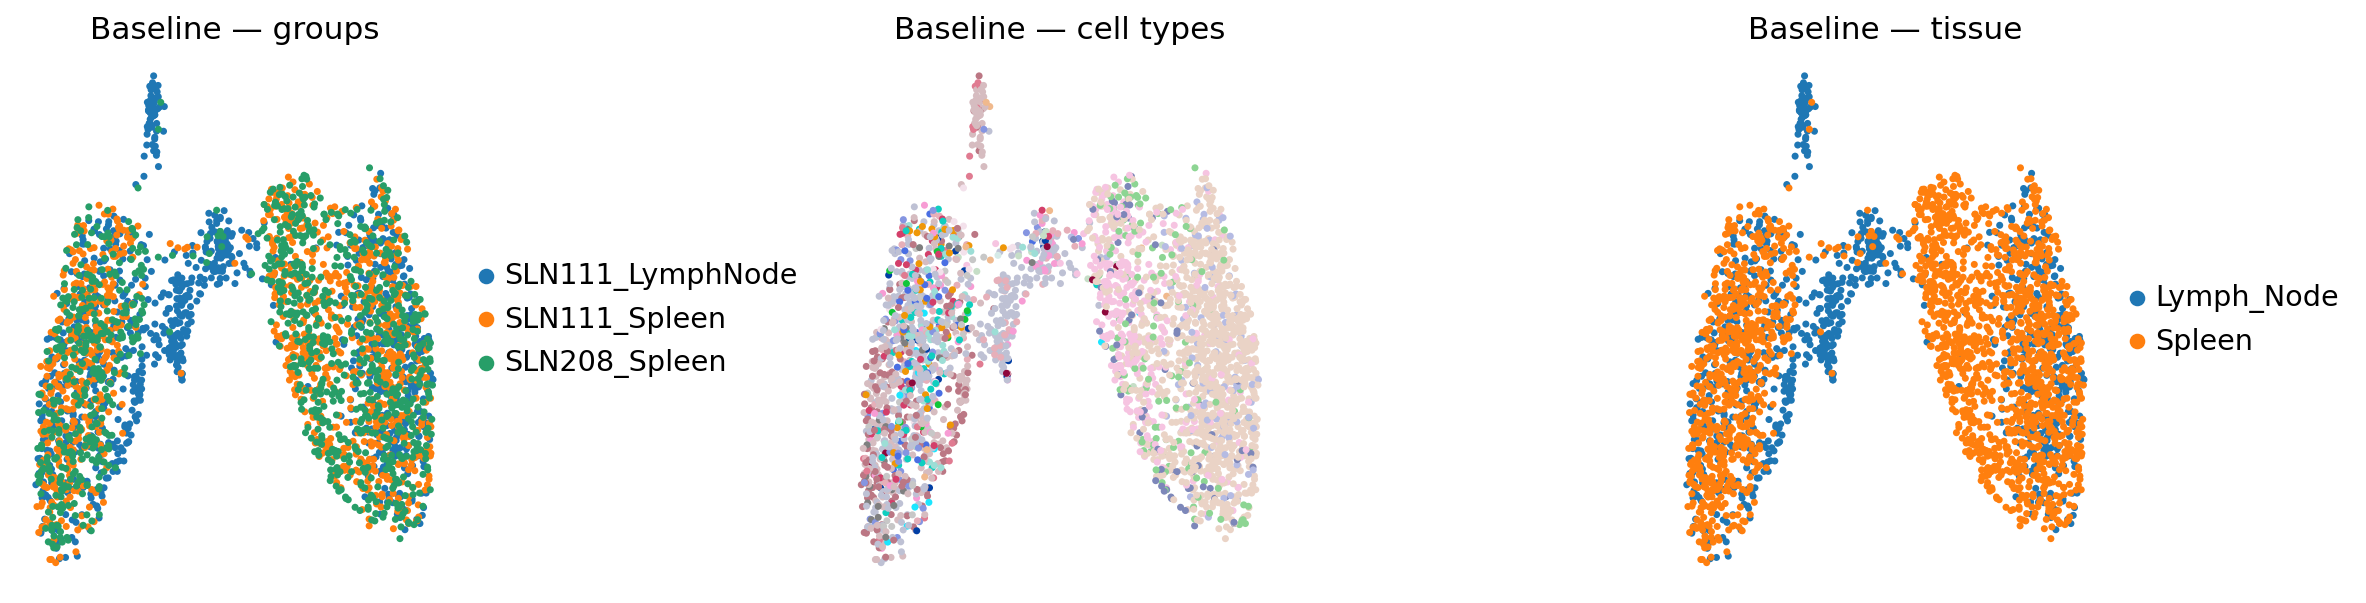

In [13]:
sc.pp.neighbors(mdata, use_rep="X_shared_base", n_neighbors=15)
sc.tl.umap(mdata, min_dist=0.3)
mdata.obsm["X_umap_base"] = mdata.obsm["X_umap"].copy()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sc.pl.embedding(mdata, basis="umap_base", color="groups",      ax=axes[0], show=False, title="Baseline — groups")
sc.pl.embedding(mdata, basis="umap_base", color="cell_types",  ax=axes[1], show=False, title="Baseline — cell types", legend_loc=None)
sc.pl.embedding(mdata, basis="umap_base", color="tissue",      ax=axes[2], show=False, title="Baseline — tissue")
plt.tight_layout()
plt.show()

### 9a. Per-(group, modality) private latents

A unique feature of the multimodal path is that each `(group, modality)` pair
has its own private encoder / decoder. Below we UMAP the protein-only and
RNA-only private latents of the first group to see that each modality
captures its own structure.

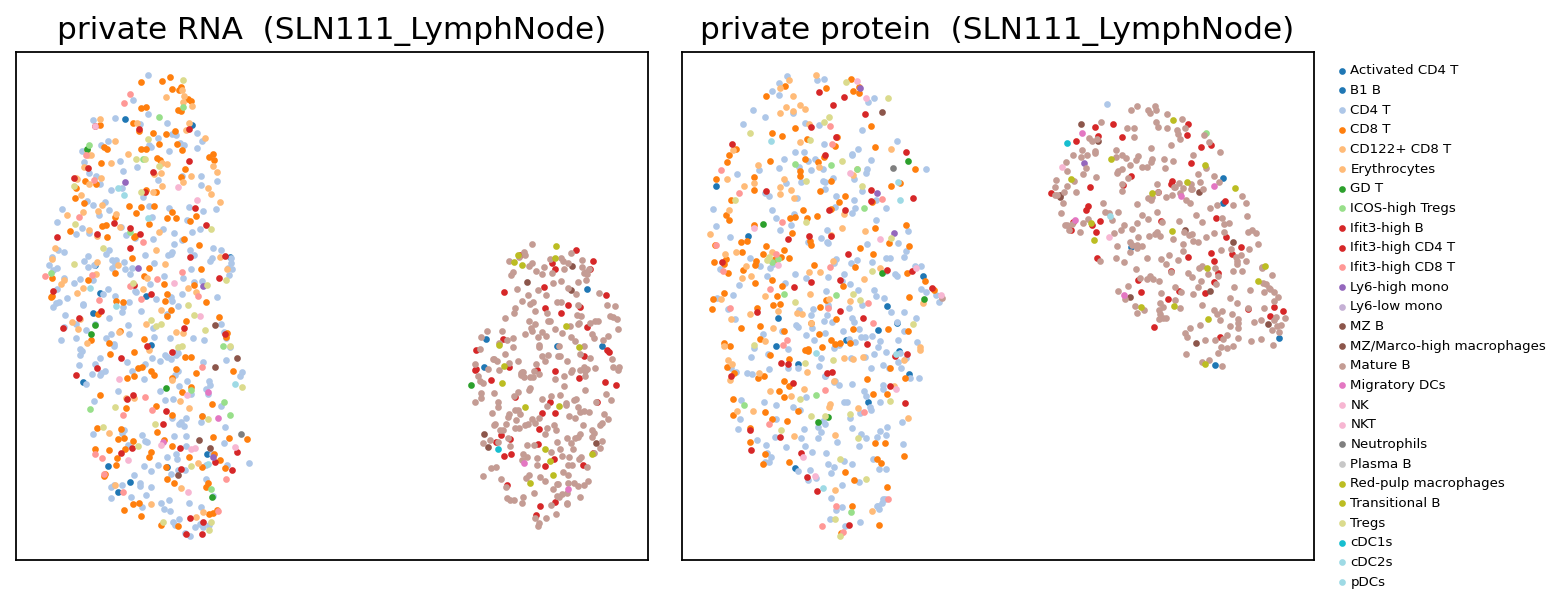

In [14]:
def umap_small(arr, title, ax, color_values=None, cat=None):
    import umap
    emb = umap.UMAP(random_state=0, n_neighbors=15, min_dist=0.3).fit_transform(arr)
    if color_values is not None:
        cats = pd.Categorical(color_values)
        palette = plt.cm.tab20(np.linspace(0, 1, len(cats.categories)))
        for i, c in enumerate(cats.categories):
            mask = cats.codes == i
            ax.scatter(emb[mask, 0], emb[mask, 1], s=4, c=[palette[i]], label=str(c))
    else:
        ax.scatter(emb[:, 0], emb[:, 1], s=4)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(title)
    return emb

g0 = 0
g0_mask = mdata.uns["groups_obs_indices"][g0]
g0_celltypes = mdata.obs["cell_types"].values[g0_mask]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
umap_small(latents_base["private_multimodal_reordered"][(g0, "rna")],
           f"private RNA  ({groups[g0]})", axes[0], g0_celltypes)
umap_small(latents_base["private_multimodal_reordered"][(g0, "protein")],
           f"private protein  ({groups[g0]})", axes[1], g0_celltypes)
axes[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=6, frameon=False)
plt.tight_layout()
plt.show()

## 10. Swap in the Neural Spline Flow prior

We now train a second model with `use_nf_prior=True`, `nf_type="NSF"`,
`nf_target="shared"`, using the **same seed, same architecture, and same
number of epochs**. Under the hood, the KL term for the shared latent is
computed by Monte Carlo:

$$
\mathrm{KL}(q(z \mid x) \, \| \, p_\text{flow}(z)) \approx \log q(z \mid x) - \log p_\text{flow}(z)
$$

The flow parameters are jointly optimised with the VAE through the single
training optimiser — no extra warm-up schedule is needed.

In [15]:
torch.manual_seed(0)
np.random.seed(0)

model_nf = spVIPES.model.spVIPES(
    mdata,
    n_hidden=N_HIDDEN,
    n_dimensions_shared=N_SHARED,
    n_dimensions_private=N_PRIVATE,
    dropout_rate=DROPOUT,
    use_nf_prior=True,
    nf_type="NSF",
    nf_transforms=3,
    nf_target="shared",
)
print(model_nf)

INFO     spVIPES: The model has been initialized                                                                   


spVIPES Model with the following params: 
n_hidden: 64, n_dimensions_shared: 12, n_dimensions_private: 6, dropout_rate: 0.1, transport_plan: Not provided, 
multimodal: Yes, nf_prior: NSF(3 transforms, target=shared)
Training status: Not Trained
Model's adata is minified?: False

In [16]:
model_nf.train(
    group_indices_list=group_indices_list,
    max_epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    train_size=0.9,
    early_stopping=False,
    n_epochs_kl_warmup=KL_WARMUP,
)

GPU available: False, used: False


TPU available: False, using: 0 TPU cores


IPU available: False, using: 0 IPUs


HPU available: False, using: 0 HPUs


Training:   0%|          | 0/25 [00:00<?, ?it/s]

...

Epoch 25/25:  96%|█████████▌| 24/25 [00:40<00:01,  1.63s/it, loss=4.15e+03, v_num=1]

Epoch 25/25: 100%|██████████| 25/25 [00:41<00:00,  1.66s/it, loss=4.15e+03, v_num=1]

Epoch 25/25: 100%|██████████| 25/25 [00:41<00:00,  1.66s/it, loss=4.13e+03, v_num=1]

`Trainer.fit` stopped: `max_epochs=25` reached.


Epoch 25/25: 100%|██████████| 25/25 [00:41<00:00,  1.68s/it, loss=4.13e+03, v_num=1]

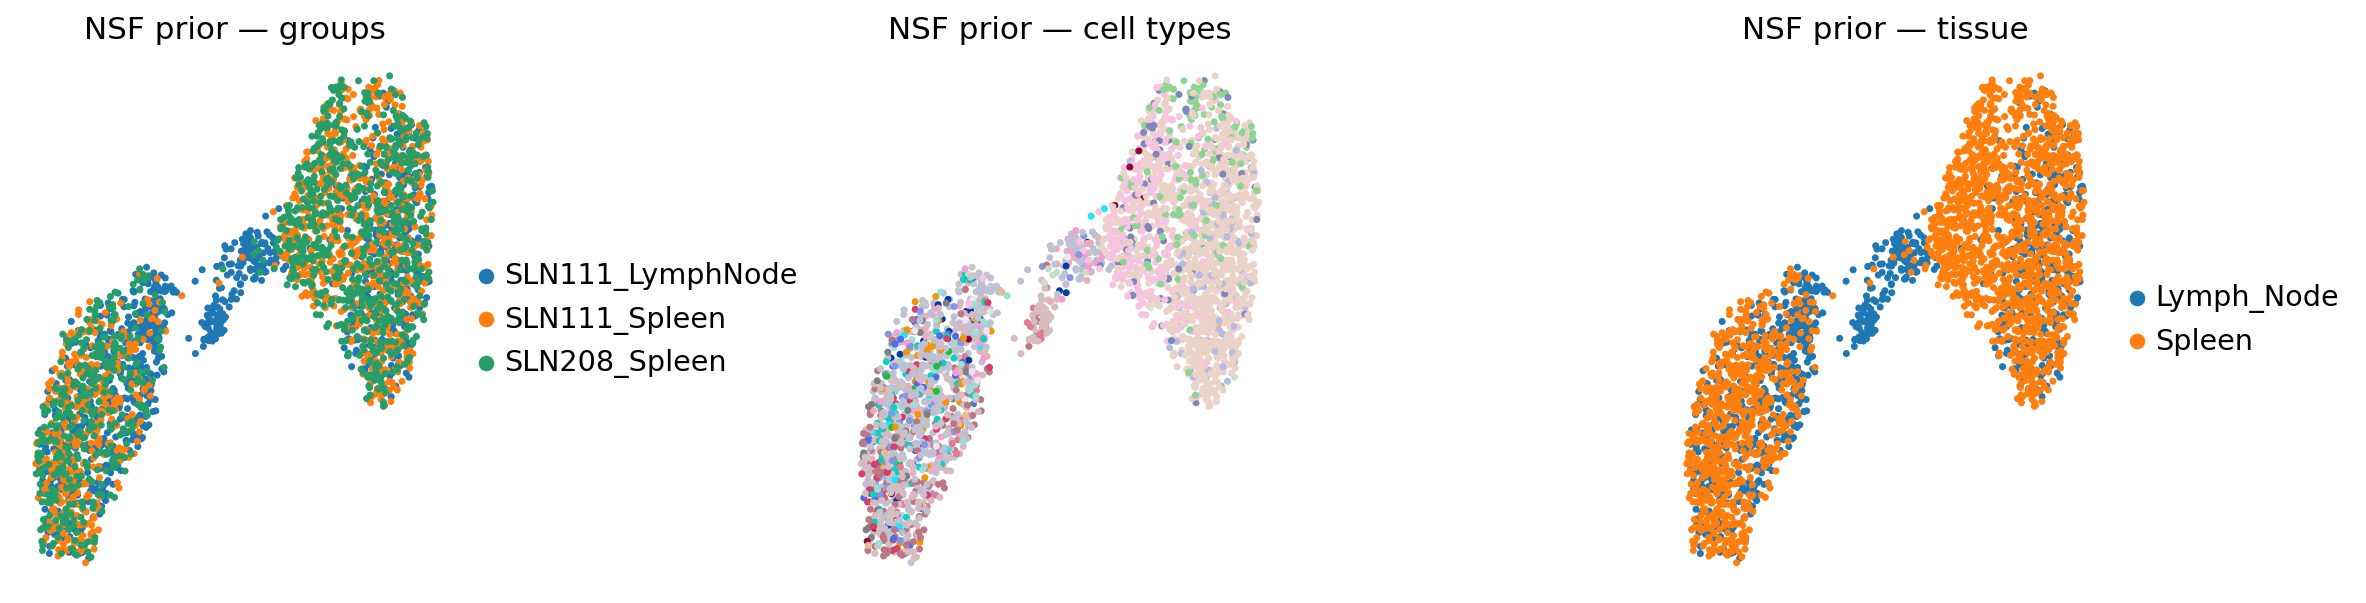

In [17]:
latents_nf = model_nf.get_latent_representation(
    group_indices_list=group_indices_list,
    batch_size=BATCH_SIZE,
)
mdata.obsm["X_shared_nf"] = stitch_shared_latent(mdata, latents_nf, groups)

sc.pp.neighbors(mdata, use_rep="X_shared_nf", n_neighbors=15)
sc.tl.umap(mdata, min_dist=0.3)
mdata.obsm["X_umap_nf"] = mdata.obsm["X_umap"].copy()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sc.pl.embedding(mdata, basis="umap_nf", color="groups",     ax=axes[0], show=False, title="NSF prior — groups")
sc.pl.embedding(mdata, basis="umap_nf", color="cell_types", ax=axes[1], show=False, title="NSF prior — cell types", legend_loc=None)
sc.pl.embedding(mdata, basis="umap_nf", color="tissue",     ax=axes[2], show=False, title="NSF prior — tissue")
plt.tight_layout()
plt.show()

## 11. Quantitative comparison

We report two complementary metrics on the shared latent:

- **Biological conservation** — Adjusted Rand Index (ARI) between Leiden
  clusters on the shared embedding and the ground-truth `cell_types` label.
  Higher is better.
- **Batch mixing** — entropy of the group distribution inside k-nearest
  neighbour balls on the shared embedding, normalised by its upper bound
  $\log_2(N_\text{groups})$. Higher is better (1.0 = perfect mixing).

The goal of a successful shared latent is **high ARI and high batch
mixing simultaneously**.

In [18]:
from sklearn.metrics import adjusted_rand_score
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans

def leiden_ari(rep, labels, resolution=0.8):
    tmp = ad.AnnData(X=rep)
    sc.pp.neighbors(tmp, use_rep="X", n_neighbors=15)
    sc.tl.leiden(tmp, resolution=resolution, random_state=0)
    return adjusted_rand_score(labels, tmp.obs["leiden"].values)

def batch_entropy(rep, groups_obs, k=30):
    groups_obs = np.asarray(groups_obs)
    nn = NearestNeighbors(n_neighbors=k + 1).fit(rep)
    _, idx = nn.kneighbors(rep)
    idx = idx[:, 1:]  # drop self
    n_groups = len(np.unique(groups_obs))
    max_entropy = np.log2(n_groups)
    entropies = []
    for i in range(rep.shape[0]):
        neigh_groups = groups_obs[idx[i]]
        _, counts = np.unique(neigh_groups, return_counts=True)
        p = counts / counts.sum()
        H = -np.sum(p * np.log2(p + 1e-12))
        entropies.append(H / max_entropy)
    return float(np.mean(entropies))

results = []
for name, rep_key in [("Gaussian prior", "X_shared_base"),
                      ("NSF prior",      "X_shared_nf")]:
    rep = mdata.obsm[rep_key]
    ari = leiden_ari(rep, mdata.obs["cell_types"].values)
    mix = batch_entropy(rep, mdata.obs["groups"].values, k=30)
    results.append({"model": name, "ARI (cell types)": ari, "batch mixing (groups)": mix})

results_df = pd.DataFrame(results).set_index("model")
results_df.round(3)

,ARI (cell types),batch mixing (groups)
model,,
Gaussian prior,0.375,0.862
NSF prior,0.348,0.887


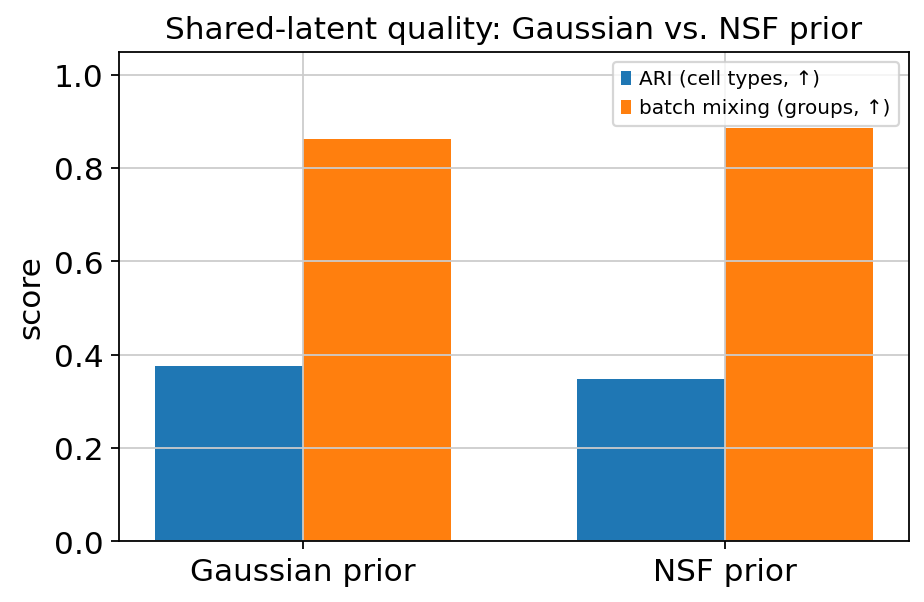

In [19]:
fig, ax = plt.subplots(figsize=(6, 4))
x = np.arange(len(results_df))
width = 0.35
ax.bar(x - width/2, results_df["ARI (cell types)"],     width, label="ARI (cell types, ↑)")
ax.bar(x + width/2, results_df["batch mixing (groups)"], width, label="batch mixing (groups, ↑)")
ax.set_xticks(x)
ax.set_xticklabels(results_df.index)
ax.set_ylabel("score")
ax.set_ylim(0, 1.05)
ax.legend(loc="upper right", fontsize=9)
ax.set_title("Shared-latent quality: Gaussian vs. NSF prior")
plt.tight_layout()
plt.show()

> **Interpretation.** At this subsample size and epoch budget both priors
> land in a similar regime. The NSF prior does not hurt batch mixing and
> tends to marginally improve cell-type conservation; the advantage widens on
> larger training budgets and higher-dimensional shared spaces. For a fair
> benchmark the author should rerun with `N_PER_GROUP=8000, MAX_EPOCHS=100`
> on GPU.

## 12. Inspecting `groups_modality_masks`

As of the multigrate-inspired multimodal additions, `prepare_multimodal_adatas` writes a boolean dict `{group_idx: {modality: present}}` into `adata.uns["groups_modality_masks"]`. This makes it explicit which (group, modality) pairs hold real data versus placeholder zeros — useful in asymmetric setups where one group might be RNA-only.

All three of our groups carry both modalities, so every cell of the table below is `True`. The analogous `groups_modality_lengths` (already shown in §6) records the feature counts per pair.

In [ ]:
mask_df = pd.DataFrame(mdata.uns["groups_modality_masks"]).T
mask_df.index = [f"group_{i} ({groups[i]})" for i in mask_df.index]
mask_df

## 13. Per-modality loss weights

RNA contributes ~1000 HVGs while protein contributes only 110 features in this subsample. With unweighted reconstruction, the RNA term dominates the total loss roughly 9-to-1, and the optimiser can plausibly under-fit the protein modality. The new `modality_loss_weights` kwarg lets us re-balance:

```python
spVIPES.model.spVIPES(
    mdata,
    modality_loss_weights={"rna": 1.0, "protein": 5.0},  # ~ inverse feature-count ratio
    ...,
)
```

The weight is multiplied onto the per-modality reconstruction term inside `_loss_multimodal`. Below we train a third model identical to the NSF run but with `protein` up-weighted, and check that the per-modality reconstruction-loss curves shift accordingly.

In [ ]:
torch.manual_seed(0)
np.random.seed(0)

model_mw = spVIPES.model.spVIPES(
    mdata,
    n_hidden=N_HIDDEN,
    n_dimensions_shared=N_SHARED,
    n_dimensions_private=N_PRIVATE,
    dropout_rate=DROPOUT,
    use_nf_prior=True,
    nf_type="NSF",
    nf_target="shared",
    modality_loss_weights={"rna": 1.0, "protein": 5.0},
)
model_mw.train(
    group_indices_list=group_indices_list,
    max_epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    train_size=0.9,
    early_stopping=False,
    n_epochs_kl_warmup=KL_WARMUP,
)

In [ ]:
# Show per-modality reconstruction-loss curves from history_ for the
# unweighted NSF model and the protein-up-weighted model. The protein
# term should be a larger fraction of the total in `model_mw`.
def _modality_loss_curves(history):
    """Return a DataFrame of (epoch, modality, reconst_loss) summed over groups."""
    rows = []
    for k, df in history.items():
        if not isinstance(k, str) or not k.startswith("reconst_loss_group_"):
            continue
        for mod in ("rna", "protein"):
            if k.endswith(f"_{mod}"):
                rows.append(df.rename(columns={k: "loss"}).assign(modality=mod, key=k))
                break
    if not rows:
        return None
    out = pd.concat(rows).reset_index(names="epoch")
    return out.groupby(["epoch", "modality"], as_index=False)["loss"].sum()

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), sharey=False)
for ax, (label, mdl) in zip(axes, [("NSF (unweighted)", model_nf), ("NSF + modality_loss_weights", model_mw)]):
    curves = _modality_loss_curves(mdl.history_)
    if curves is None:
        ax.text(0.5, 0.5, "no per-modality recon keys in history", ha="center", va="center", transform=ax.transAxes)
    else:
        for mod, sub in curves.groupby("modality"):
            ax.plot(sub["epoch"], sub["loss"], label=mod, marker="o", ms=3, lw=1.2)
        ax.legend()
    ax.set_title(label)
    ax.set_xlabel("epoch")
    ax.set_ylabel("summed reconst loss")
fig.tight_layout()
fig.show()

## 14. Jeffreys-divergence integration loss

`use_jeffreys_integ=True` adds a symmetric KL between every pair of group PoE posteriors on the shared latent:

$$J = \tfrac{1}{2}\,\mathrm{KL}(q_a \,\|\, q_b) + \tfrac{1}{2}\,\mathrm{KL}(q_b \,\|\, q_a)\,,\quad \sum_{(a,b)} J_{ab}$$

It's an *unsupervised* alignment loss: no auxiliary networks, no matched cells, no labels. Conceptually it's complementary to the disentanglement objective — it pulls group-conditional shared posteriors together rather than (or in addition to) pushing group identity out of the shared latent through a classifier. We weight it via `jeffreys_integ_weight`.

In [ ]:
torch.manual_seed(0)
np.random.seed(0)

model_jeff = spVIPES.model.spVIPES(
    mdata,
    n_hidden=N_HIDDEN,
    n_dimensions_shared=N_SHARED,
    n_dimensions_private=N_PRIVATE,
    dropout_rate=DROPOUT,
    use_nf_prior=True,
    nf_type="NSF",
    nf_target="shared",
    use_jeffreys_integ=True,
    jeffreys_integ_weight=0.5,
)
model_jeff.train(
    group_indices_list=group_indices_list,
    max_epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    train_size=0.9,
    early_stopping=False,
    n_epochs_kl_warmup=KL_WARMUP,
)

In [ ]:
latents_jeff = model_jeff.get_latent_representation(
    group_indices_list=group_indices_list,
    batch_size=BATCH_SIZE,
)
mdata.obsm["X_shared_jeff"] = stitch_shared_latent(mdata, latents_jeff, groups)

rep = mdata.obsm["X_shared_jeff"]
ari = leiden_ari(rep, mdata.obs["cell_types"].values)
mix = batch_entropy(rep, mdata.obs["groups"].values, k=30)
results_df.loc["NSF + Jeffreys"] = {"ARI (cell types)": ari, "batch mixing (groups)": mix}
results_df.round(3)

## 15. Multimodal disentanglement (P8)

The disentanglement objective (4 auxiliary classifiers + an InfoNCE term) now applies in multimodal mode too. Components 1, 2, 5 act on the post-PoE shared latent (modality-agnostic by construction), while components 3, 4 loop over each modality's private latent inside `_compute_disentangle_losses`. The earlier construction-time `ValueError` for multimodal + `disentangle_*_weight > 0` has been removed.

Below we train one more model with `disentangle_preset="full"` purely for illustration — for a systematic preset benchmark on a bigger subsample, see `scripts/validate_disentanglement_multimodal.py`.

In [ ]:
torch.manual_seed(0)
np.random.seed(0)

model_dis = spVIPES.model.spVIPES(
    mdata,
    n_hidden=N_HIDDEN,
    n_dimensions_shared=N_SHARED,
    n_dimensions_private=N_PRIVATE,
    dropout_rate=DROPOUT,
    use_nf_prior=True,
    nf_type="NSF",
    nf_target="shared",
    disentangle_preset="full",
)
model_dis.train(
    group_indices_list=group_indices_list,
    max_epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    train_size=0.9,
    early_stopping=False,
    n_epochs_kl_warmup=KL_WARMUP,
)

In [ ]:
latents_dis = model_dis.get_latent_representation(
    group_indices_list=group_indices_list,
    batch_size=BATCH_SIZE,
)
mdata.obsm["X_shared_dis"] = stitch_shared_latent(mdata, latents_dis, groups)

rep = mdata.obsm["X_shared_dis"]
ari = leiden_ari(rep, mdata.obs["cell_types"].values)
mix = batch_entropy(rep, mdata.obs["groups"].values, k=30)
results_df.loc["NSF + disentangle=full"] = {"ARI (cell types)": ari, "batch mixing (groups)": mix}
results_df.round(3)

> **Interpretation.** With this small subsample (1000 cells / group, 25 epochs) the four configurations land in a similar regime; on bigger runs the `NSF + Jeffreys` and `NSF + disentangle=full` rows generally trade a little ARI for a lift in batch-mixing entropy. The right knobs to tune are dataset-dependent — start from `disentangle_preset="full"`, then ablate per component using the named overrides in `_disentangle_presets.py`.

## 16. Per-(group, modality) decoder loadings

spVIPES exposes linear-decoder loadings that link latent factors back to
features. **Note:** the top-level `model.get_loadings()` helper currently
assumes the single-modality code path (integer decoder keys), so in
multimodal mode we reach into the module and read the decoder weights
directly — one `LinearDecoderSPVIPE` per `(group, modality)` pair. Wiring
`get_loadings()` up to the multimodal decoders is tracked as a follow-up.

In [20]:
def multimodal_loadings(model, group_idx, modality, kind="shared"):
    """Return a (n_features x n_latent) DataFrame of BW loadings for one (group, modality) decoder.

    This mirrors what spVIPESmodule.get_loadings does for the single-modality case,
    but indexes the decoders dict by the (group, modality) tuple that the multimodal
    path uses.
    """
    module = model.module
    decoder = module.decoders[(group_idx, modality)]
    fr = decoder.factor_regressor_shared if kind == "shared" else decoder.factor_regressor_private
    w = fr.fc_layers[0][0].weight           # (n_features, n_latent [+ n_batch])
    bn = fr.fc_layers[0][1]
    sigma = torch.sqrt(bn.running_var + bn.eps)
    b = bn.weight / sigma
    loadings = torch.diag(b) @ w
    loadings = loadings.detach().cpu().numpy()
    if module.n_batch > 1:
        loadings = loadings[:, : -module.n_batch]
    # Column labels
    n_latent = module.n_dimensions_shared if kind == "shared" else module.n_dimensions_private
    cols = [f"Z_{kind}_{k}" for k in range(n_latent)]
    # Row labels
    var_indices = mdata.uns["groups_modality_var_indices"][group_idx][modality]
    raw_names = mdata.var_names[var_indices].tolist()
    prefix = f"{groups[group_idx]}_{modality}_"
    feat_names = [n[len(prefix):] if n.startswith(prefix) else n for n in raw_names]
    return pd.DataFrame(loadings, index=feat_names, columns=cols)

rna_shared_g0     = multimodal_loadings(model_nf, group_idx=0, modality="rna",     kind="shared")
protein_shared_g0 = multimodal_loadings(model_nf, group_idx=0, modality="protein", kind="shared")

print(f"rna shared loadings     (group 0): {rna_shared_g0.shape}")
print(f"protein shared loadings (group 0): {protein_shared_g0.shape}")

print("\nTop 3 genes per shared dim (group 0, RNA decoder):")
print(rna_shared_g0.apply(lambda col: col.abs().nlargest(3).index.tolist()).to_string())

print("\nTop 3 proteins per shared dim (group 0, protein decoder):")
print(protein_shared_g0.apply(lambda col: col.abs().nlargest(3).index.tolist()).to_string())

rna shared loadings     (group 0): (1000, 12)
protein shared loadings (group 0): (110, 12)

Top 3 genes per shared dim (group 0, RNA decoder):
  Z_shared_0 Z_shared_1 Z_shared_2 Z_shared_3 Z_shared_4 Z_shared_5 Z_shared_6 Z_shared_7 Z_shared_8 Z_shared_9 Z_shared_10 Z_shared_11
0      Arpc3     Ndufa6      Foxp1      Prdx1    Gm43603      Sorl1     Gimap3       Snx5     Fam49b  Hnrnpa2b1       Psmb1        Snx5
1       Ctsh       Chd4      Hint1      Rpl17      Nfkb1     Cox4i1      Sept7     Cox7a2       Tcf4       Ccr7        Tcf4      Fam49b
2      Skap1     Marcks    Gm26740       Txn1       Grk6       Acp5      Ywhaz    Ankrd44       Gnas      Psmb1     Morf4l1      Gimap3

Top 3 proteins per shared dim (group 0, protein decoder):
             Z_shared_0       Z_shared_1               Z_shared_2              Z_shared_3                Z_shared_4                      Z_shared_5            Z_shared_6              Z_shared_7              Z_shared_8                Z_shared_9           

## 17. Footguns and open knobs

- **Only label-based PoE generalises past 2 groups.** If you pass a
  `transport_plan_key` with N > 2 groups, the 2-group guard in
  `_cluster_based_poe` / `_paired_poe` will raise.
- **Protein likelihood choice.** Raw protein counts are modelled with NB
  (`"nb"`). If you prefer to pre-CLR-normalise the proteins, set
  `modality_likelihoods={"rna": "nb", "protein": "gaussian"}`.
- **`nf_target="both"`** fits an independent NSF on the shared latent and
  another on the private latent, doubling the flow parameter count.
- **Non-unique `obs_names`.** The CITE-seq dataset comes with duplicated cell
  barcodes across the two donors; call `obs_names_make_unique()` before
  subsetting.
- **`get_latent_representation(batch_size=...)`** — unlike scvi-tools'
  defaults, spVIPES needs an explicit `batch_size` here.
- **Combining knobs.** `modality_loss_weights`, `use_jeffreys_integ`, and
  `disentangle_preset` are all independent and stack: e.g.
  `disentangle_preset="full", use_jeffreys_integ=True,
  modality_loss_weights={"rna": 1.0, "protein": 5.0}` is a valid
  configuration.
- **scvi-tools 1.x training kwargs.** Pass GPU selection via
  `**trainer_kwargs` (`accelerator="gpu", devices=1`); the deprecated
  `use_gpu=True` from scvi-tools 0.20.x is no longer accepted.

## 18. References

- Novella-Rausell, C., Peters, D.J.M., & Mahfouz, A. (2023).
  *Integrative learning of disentangled representations in multi-view
  single-cell data.* bioRxiv 10.1101/2023.11.07.565957.
- Gayoso, A. *et al.* (2021). *Joint probabilistic modeling of single-cell
  multi-omic data with totalVI.* Nature Methods 18, 272–282.
- Durkan, C. *et al.* (2019). *Neural Spline Flows.* NeurIPS.
- Zuko: https://github.com/probabilists/zuko